<a href="https://colab.research.google.com/github/dipanshugarg13/Predictive-Analytics-Project/blob/main/Engineering_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# **Dataset Loading**

In [4]:
df = pd.read_csv('/content/indian_engineering_student_placement.csv')
df.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


In [5]:
df

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,Female,IT,10.00,90.4,98.3,0,3.7,75.3,6,...,2,7.3,2,No,Medium,Tier 3,Yes,Low,Placed,19.35
4996,4997,Male,IT,7.76,74.3,72.6,2,6.3,72.3,4,...,2,7.8,6,No,Low,Tier 1,Yes,Low,Not Placed,0.00
4997,4998,Male,IT,7.79,64.0,71.2,2,2.0,63.8,6,...,2,6.1,5,Yes,Low,Tier 2,No,Medium,Placed,19.13
4998,4999,Female,ECE,8.76,74.3,74.0,0,5.1,72.0,6,...,5,9.0,10,No,Medium,Tier 2,Yes,High,Placed,16.53


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   object 
 2   branch                       5000 non-null   object 
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  aptitude_skill_rat

# **Descriptive Statistics**

In [ ]:
df.describe()

,Student_ID,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,salary_lpa
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,8.283798,74.537400,74.543060,0.343600,4.041120,72.041560,5.529400,2.132600,3.728600,3.025400,4.116400,3.704200,2.836000,6.955000,6.020200,13.897180
std,1443.520003,1.008391,10.266752,10.244481,0.612547,1.967754,7.720029,2.053772,1.143713,1.278464,1.412358,0.716208,1.603252,1.781724,1.147881,2.851213,6.247481
min,1.000000,5.000000,50.000000,50.000000,0.000000,0.000000,44.700000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000
25%,1250.750000,7.610000,67.400000,67.600000,0.000000,2.700000,66.600000,4.000000,1.000000,3.000000,2.000000,4.000000,3.000000,2.000000,6.200000,4.000000,12.510000
50%,2500.500000,8.320000,74.700000,74.800000,0.000000,4.000000,72.050000,6.000000,2.000000,4.000000,3.000000,4.000000,4.000000,3.000000,7.000000,6.000000,15.760000
75%,3750.250000,9.020000,82.000000,81.700000,1.000000,5.400000,77.200000,7.000000,3.000000,5.000000,4.000000,5.000000,5.000000,4.000000,7.800000,9.000000,18.332500
max,5000.000000,10.000000,100.000000,100.000000,5.000000,10.000000,99.200000,8.000000,4.000000,5.000000,5.000000,5.000000,6.000000,9.000000,9.000000,10.000000,20.000000


In [ ]:
df.select_dtypes(include=np.number).corr()

,Student_ID,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,salary_lpa
Student_ID,1.000000,0.012772,0.003649,0.008258,-0.004586,0.011003,0.014075,-0.013529,0.022216,-0.011285,0.005771,0.019044,0.002498,-0.010571,-0.004791,0.000009,-0.000849
cgpa,0.012772,1.000000,0.880473,0.872270,-0.305875,0.268219,0.202225,0.205021,0.558580,0.232225,0.006288,0.661614,0.195218,0.079264,0.054210,-0.127415,0.549533
tenth_percentage,0.003649,0.880473,1.000000,0.765094,-0.278136,0.242750,0.180658,0.189939,0.495474,0.213462,0.005854,0.586603,0.175054,0.071546,0.040241,-0.112947,0.481920
twelfth_percentage,0.008258,0.872270,0.765094,1.000000,-0.268196,0.243754,0.181201,0.167963,0.488378,0.190098,0.003754,0.567747,0.166907,0.060870,0.046709,-0.102676,0.471026
backlogs,-0.004586,-0.305875,-0.278136,-0.268196,1.000000,-0.090390,-0.069045,-0.068773,-0.167554,-0.075287,0.001240,-0.184201,-0.072884,-0.014892,-0.032800,0.028096,-0.410192
study_hours_per_day,0.011003,0.268219,0.242750,0.243754,-0.090390,1.000000,0.763632,0.046571,0.161996,0.051121,0.002921,0.181878,0.041495,-0.010600,-0.010216,-0.008677,0.132681
attendance_percentage,0.014075,0.202225,0.180658,0.181201,-0.069045,0.763632,1.000000,0.031709,0.113652,0.023742,0.011542,0.133415,0.016932,-0.003777,-0.013357,-0.007379,0.091106
projects_completed,-0.013529,0.205021,0.189939,0.167963,-0.068773,0.046571,0.031709,1.000000,0.111052,0.891180,-0.006292,0.130677,0.699562,0.313848,0.016089,-0.037149,0.456588
internships_completed,0.022216,0.558580,0.495474,0.488378,-0.167554,0.161996,0.113652,0.111052,1.000000,0.126813,0.012156,0.369689,0.107033,0.047977,0.051705,-0.074557,0.469054
coding_skill_rating,-0.011285,0.232225,0.213462,0.190098,-0.075287,0.051121,0.023742,0.891180,0.126813,1.000000,0.004483,0.147894,0.785306,0.346925,0.014699,-0.043605,0.496776


In [ ]:
df.duplicated().sum()

np.int64(0)

# **Data Cleaning**

In [ ]:
df.isnull().sum()

,0
Student_ID,0
gender,0
branch,0
cgpa,0
tenth_percentage,0
twelfth_percentage,0
backlogs,0
study_hours_per_day,0
attendance_percentage,0
projects_completed,0


# **Catagoerical Count**

In [ ]:
print("\nValue Counts for Categorical Features:")
for col in ['extracurricular_involvement', 'placement_status']:
    print(f"Column: {col}")
    display(df[col].value_counts())


Value Counts for Categorical Features:
Column: extracurricular_involvement


,count
extracurricular_involvement,
Medium,1501
Low,1485
High,1008


Column: placement_status


,count
placement_status,
Placed,4303
Not Placed,697


# **Relation Between Variables - Scatter Plot**

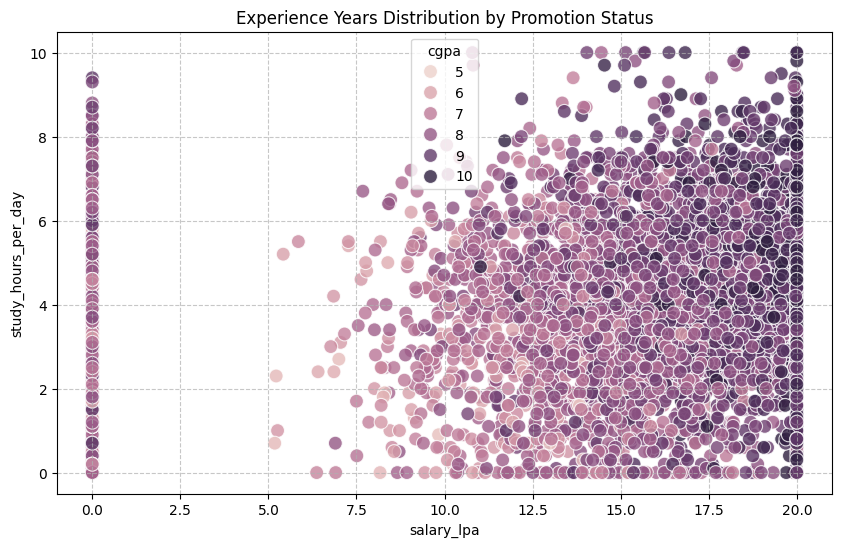

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='salary_lpa', y='study_hours_per_day', hue='cgpa', data=df, s=100, alpha=0.8)
plt.title('Experience Years Distribution by Promotion Status')
plt.xlabel('salary_lpa')
plt.ylabel('study_hours_per_day')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='cgpa')
plt.show()

# **Correlation Matrix**

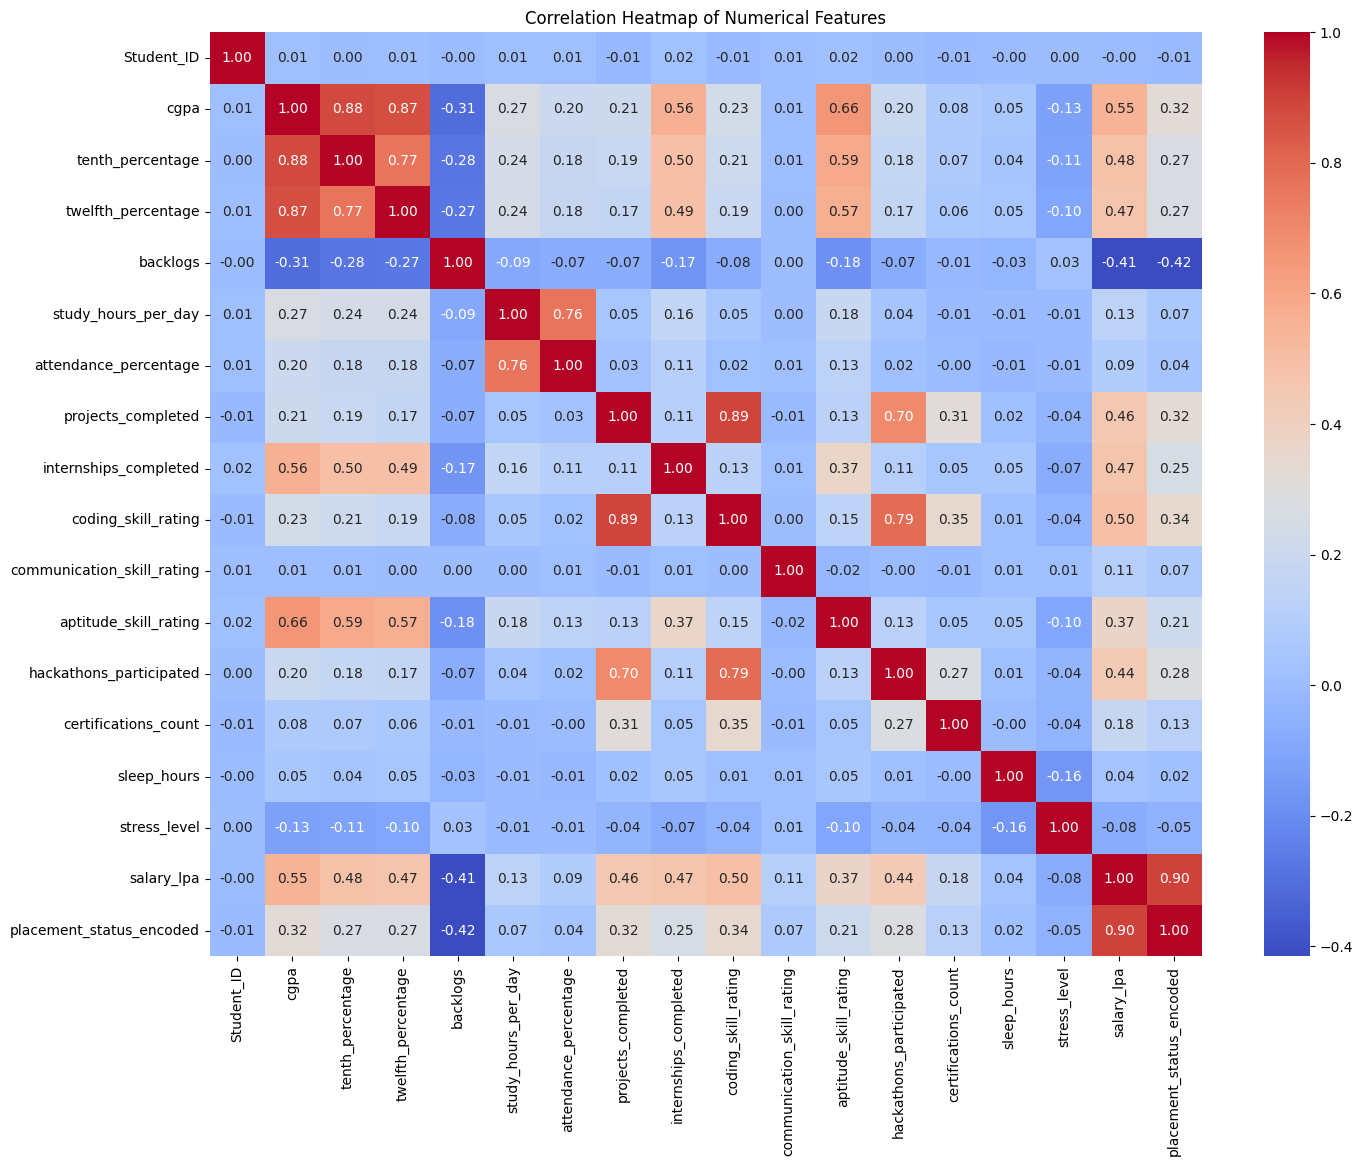

In [ ]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

#                                   **`Data Visualisation `**

/tmp/ipykernel_17304/2399908237.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='branch', y='count', data=branch_counts, palette='viridis')


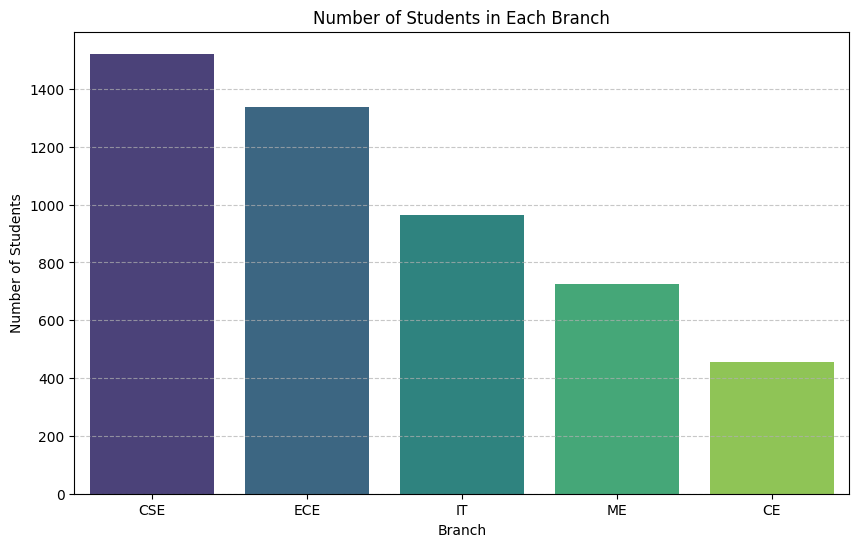

In [ ]:
branch_counts = df['branch'].value_counts().reset_index()
branch_counts.columns = ['branch', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(x='branch', y='count', data=branch_counts, palette='viridis')
plt.title('Number of Students in Each Branch')
plt.xlabel('Branch')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Let's explore the relationship between average sleep hours and average stress level, considering the students' CGPA.

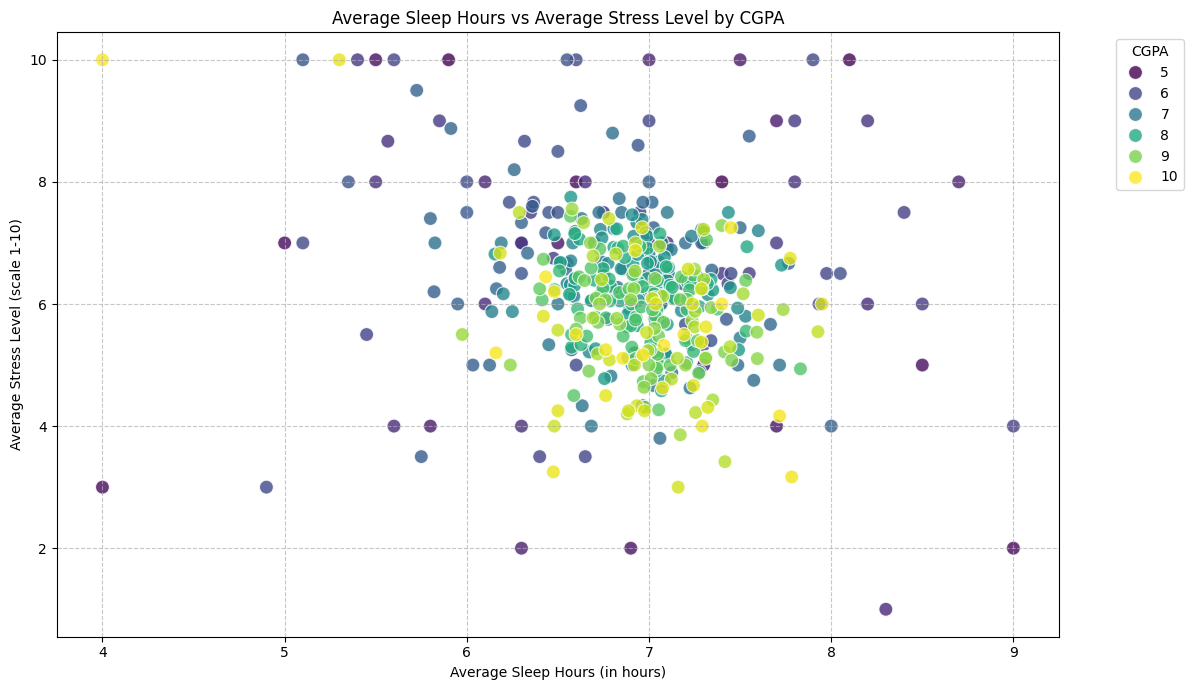

In [ ]:
# Aggregate the DataFrame by 'cgpa' to calculate the mean of 'sleep_hours' and 'stress_level'
df_aggregated_by_cgpa = df.groupby('cgpa')[['sleep_hours', 'stress_level']].mean().reset_index()

# Create the scatter plot
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_aggregated_by_cgpa,
    x='sleep_hours',
    y='stress_level',
    hue='cgpa',  # Color points based on CGPA values
    s=100,       # Set point size
    alpha=0.8,   # Set transparency
    palette='viridis' # Choose a color palette suitable for continuous data
)

plt.title('Average Sleep Hours vs Average Stress Level by CGPA')
plt.xlabel('Average Sleep Hours (in hours)')
plt.ylabel('Average Stress Level (scale 1-10)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='CGPA', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside to avoid overlap
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [6]:
df.columns

Index(['Student_ID', 'gender', 'branch', 'cgpa', 'tenth_percentage',
       'twelfth_percentage', 'backlogs', 'study_hours_per_day',
       'attendance_percentage', 'projects_completed', 'internships_completed',
       'coding_skill_rating', 'communication_skill_rating',
       'aptitude_skill_rating', 'hackathons_participated',
       'certifications_count', 'sleep_hours', 'stress_level', 'part_time_job',
       'family_income_level', 'city_tier', 'internet_access',
       'extracurricular_involvement', 'placement_status', 'salary_lpa'],
      dtype='object')

In [12]:
first = df[['Student_ID', 'gender', 'branch', 'cgpa', 'tenth_percentage',
       'twelfth_percentage', 'backlogs', 'study_hours_per_day',
       'attendance_percentage', 'projects_completed', 'internships_completed',
       'coding_skill_rating', 'communication_skill_rating',
       'aptitude_skill_rating', 'hackathons_participated',
       'certifications_count', 'sleep_hours', 'stress_level', 'part_time_job',
       'family_income_level', 'city_tier', 'internet_access',
       'extracurricular_involvement', 'placement_status', 'salary_lpa']]

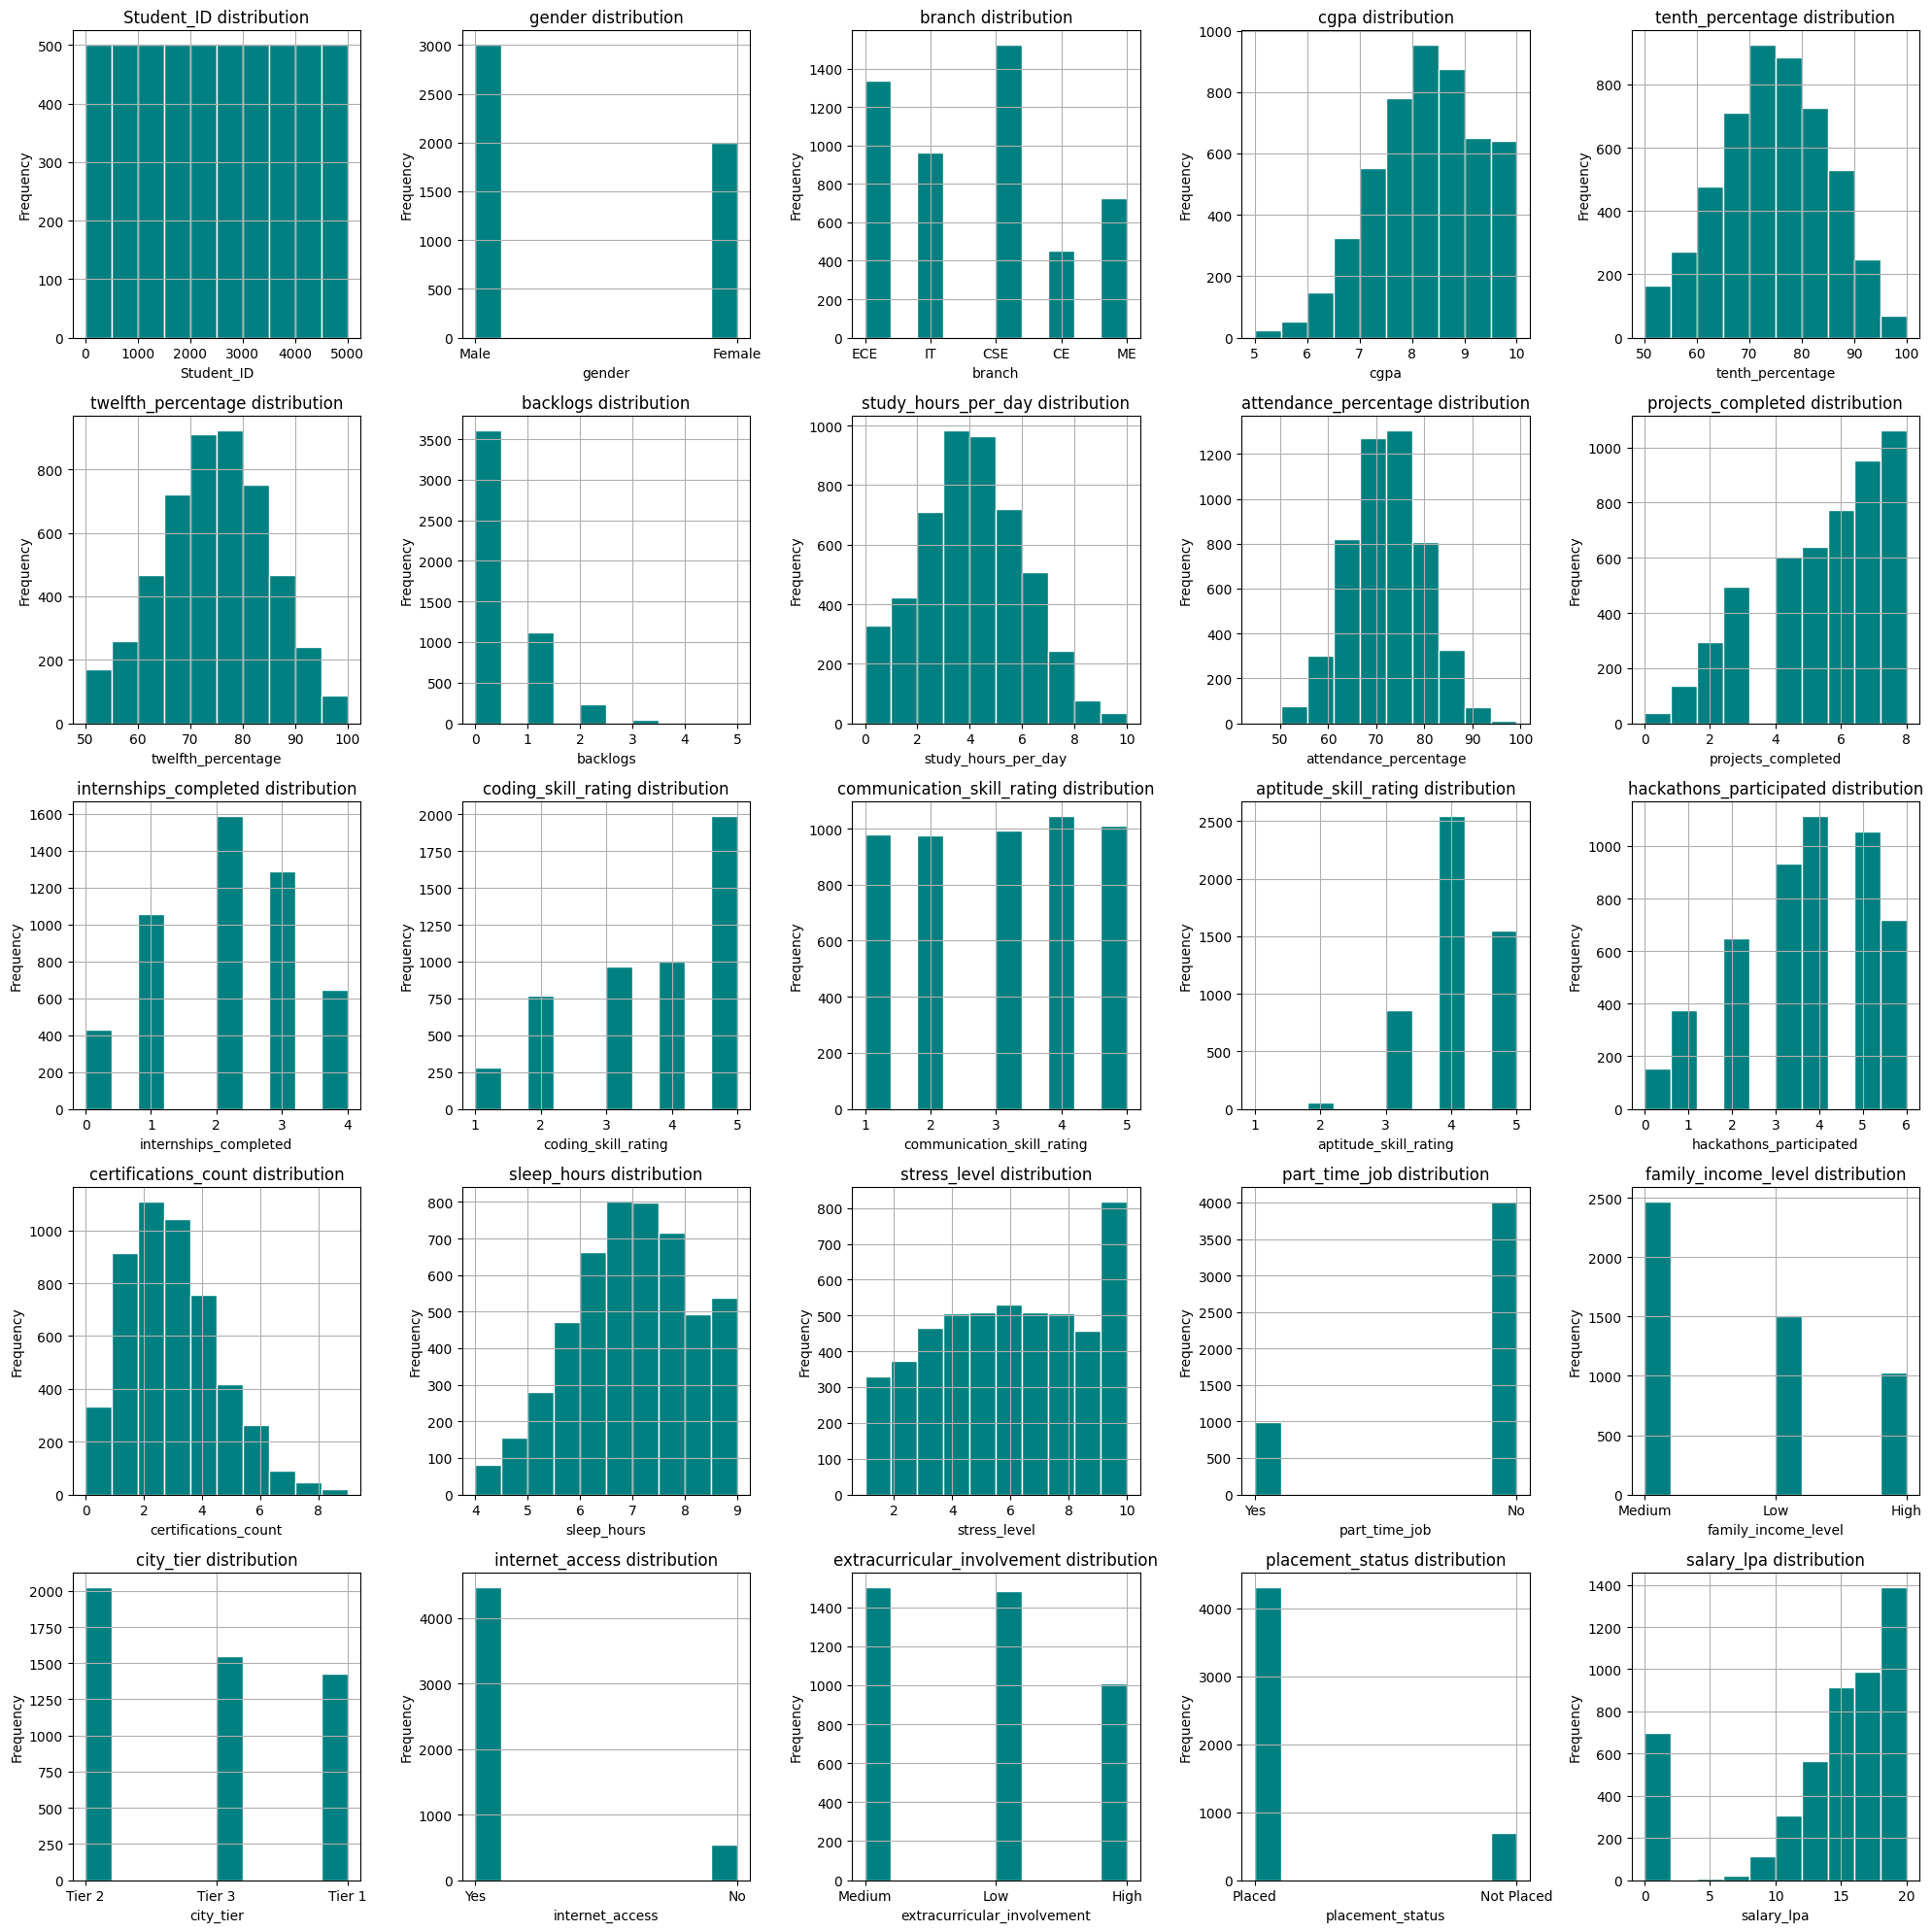

In [13]:
fig, axes = plt.subplots(nrows = 5, ncols = 5, figsize=(20, 20))
axes = axes.flatten()

for i, column in enumerate(first.columns):
    first[column].hist(ax = axes[i], edgecolor='white', color = 'teal')

    axes[i].set_title(f'{column} distribution')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

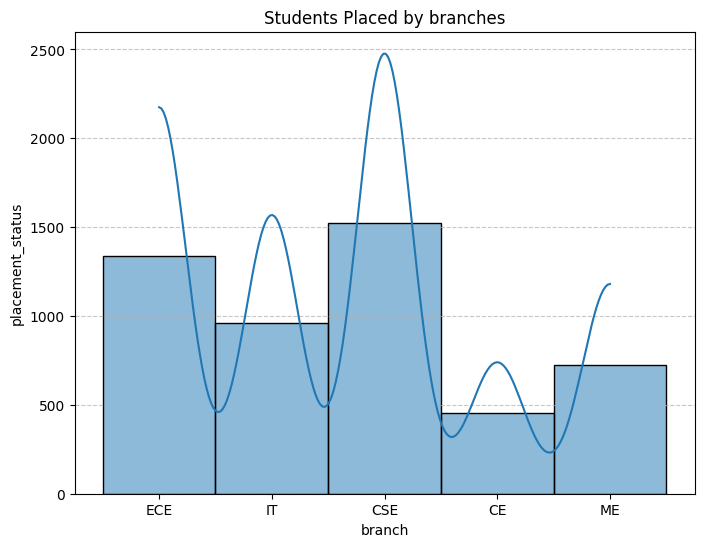

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['branch'], bins=df['placement_status'].nunique(), kde=True)
plt.title('Students Placed by branches')
plt.xlabel('branch')
plt.ylabel('placement_status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Branch-wise distribution of placed students

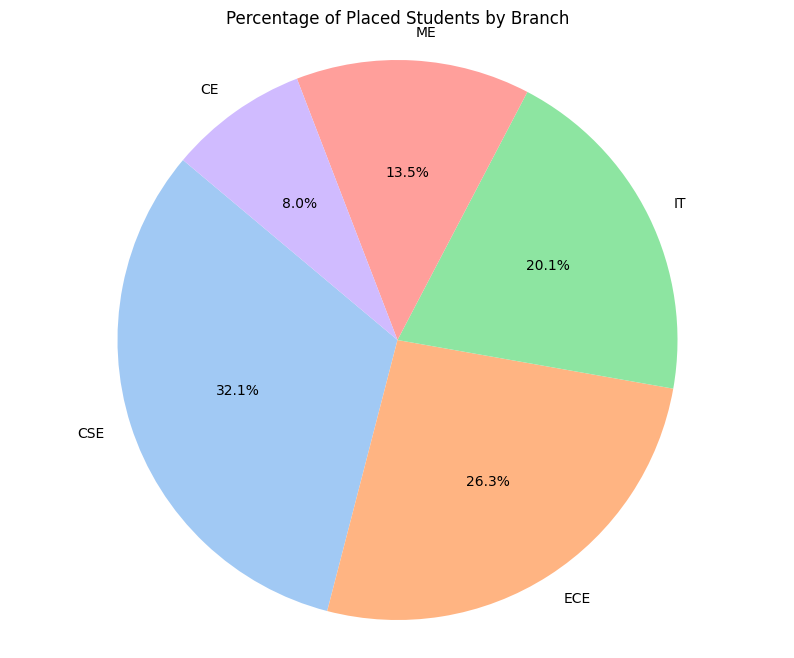

In [ ]:
# Filter for placed students
placed_students_df = df[df['placement_status'] == 'Placed']

# Get the count of placed students per branch
placed_branch_counts = placed_students_df['branch'].value_counts()

# Create the pie chart
plt.figure(figsize=(10, 8))
plt.pie(placed_branch_counts, labels=placed_branch_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Percentage of Placed Students by Branch')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier # Import DecisionTreeClassifier

# Encode the 'placement_status' column (similar to 'Promotion')
le_placement_status = LabelEncoder()
df['placement_status_encoded'] = le_placement_status.fit_transform(df['placement_status'])

# Define features (X) and target (y)
# Using 'cgpa' and 'study_hours_per_day' as features, similar to 'Experience' and 'Performance_Encoded'
X = df[['cgpa', 'study_hours_per_day']]
y = df['placement_status_encoded']

# Initialize and train the Decision Tree Classifier with a limited max_depth
dtree_classifier = DecisionTreeClassifier(max_depth=3)
dtree_classifier.fit(X, y)

print("Decision Tree Classifier trained successfully using 'cgpa', 'study_hours_per_day' to predict 'placement_status'!")

Decision Tree Classifier trained successfully using 'cgpa', 'study_hours_per_day' to predict 'placement_status'!


This cell sets up and trains a Decision Tree Classifier. It uses LabelEncoder to convert the placement_status column into a numerical format (placement_status_encoded). Then, it defines cgpa and study_hours_per_day as features (X) and the encoded placement status as the target (y). A DecisionTreeClassifier is initialized with max_depth=3 (to prevent overfitting and make the tree interpretable) and trained on the data.

# **Decision Tree**

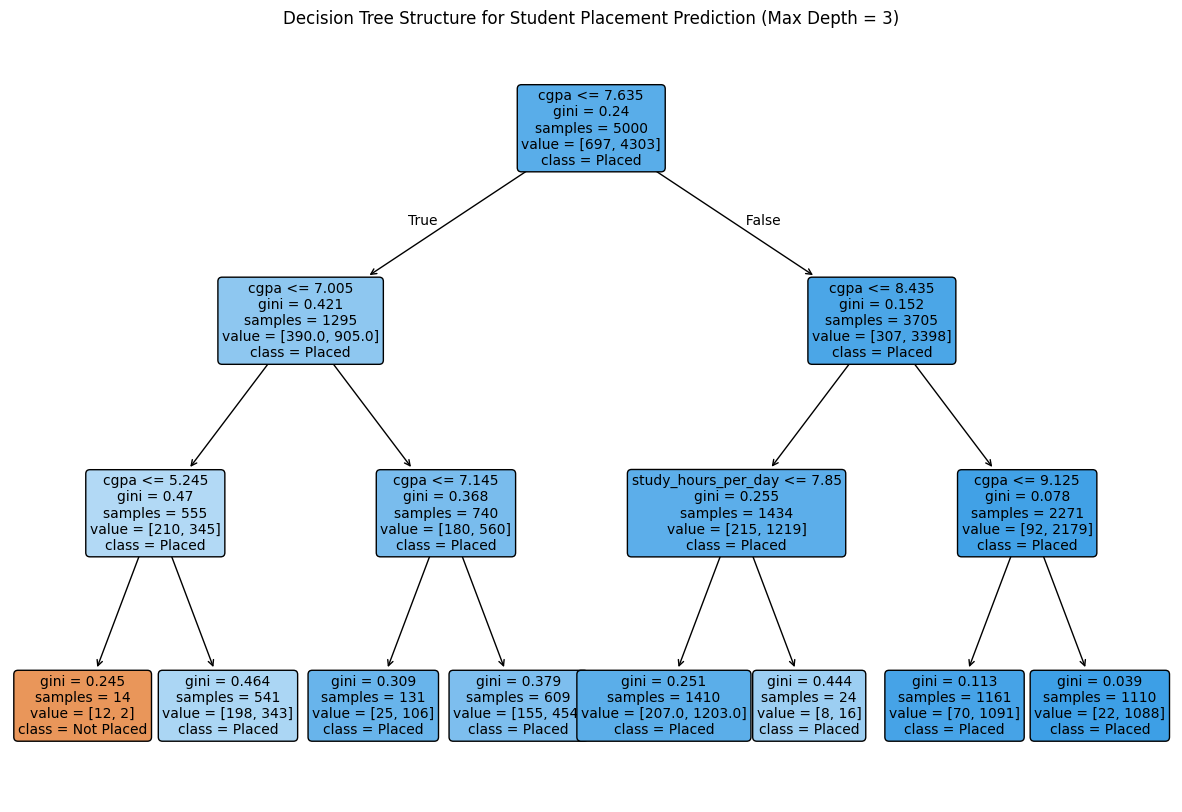

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(15, 10))
tree.plot_tree(dtree_classifier,
               feature_names=X.columns.tolist(),
               class_names=le_placement_status.classes_,
               filled=True,
               rounded=True,
               fontsize=10)
plt.title('Decision Tree Structure for Student Placement Prediction (Max Depth = 3)')
plt.show()

This cell uses sklearn.tree.plot_tree to visualize the trained dtree_classifier. It labels the features and classes, fills the nodes with colors based on class, and rounds the node corners for better readability. The max_depth=3 makes this visualization clear.

# **Traning Model**

In [ ]:
# Define data for a new student to make a prediction
new_student_data = pd.DataFrame({
    'cgpa': [8.0],  # Example CGPA for a new student
    'study_hours_per_day': [7.0] # Example study hours per day for a new student
})

# Use the trained Decision Tree Classifier to predict placement status
prediction_encoded = dtree_classifier.predict(new_student_data)

# Convert the encoded prediction back to the original categorical label
prediction_status = le_placement_status.inverse_transform(prediction_encoded)

print(f"Predicted placement status for the new student: {prediction_status[0]}")

Predicted placement status for the new student: Placed


This cell demonstrates how to use the trained dtree_classifier to predict the placement status for a new, hypothetical student. It takes cgpa and study_hours_per_day as input, makes a prediction, and then converts the numerical prediction back to the original categorical label ('Placed' or 'Not Placed').

In [18]:
from sklearn.preprocessing import LabelEncoder

# Re-encode the 'placement_status' column if it's not already present
if 'placement_status_encoded' not in df.columns:
    le_placement_status = LabelEncoder()
    df['placement_status_encoded'] = le_placement_status.fit_transform(df['placement_status'])

X = df[['study_hours_per_day']]
y = df['placement_status_encoded']

This cell re-prepares the features (X) and target (y) for a new model, Logistic Regression. It ensures placement_status_encoded is available and uses only study_hours_per_day as the feature.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

This cell splits the X (features) and y (target) data into training and testing sets using train_test_split. test_size=0.2 means 20% of the data will be used for testing, and 80% for training.

# **Logistic Regression**

In [20]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

This cell initializes a LogisticRegression model and then trains it using the X_train and y_train data.

# **Predictive Model**

In [21]:
predictions = model.predict(X_test)

This cell uses the trained LogisticRegression model to make predictions on the X_test dataset. The results are stored in the predictions variable.

In [22]:
from sklearn.metrics import accuracy_score
accuracy_score = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy_score}")

Accuracy: 0.865


This cell calculates and prints the accuracy score of the LogisticRegression model by comparing its predictions on the test set with the actual y_test values.

In [23]:
pred = model.predict([[3]])
pred

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

This cell demonstrates how to make a prediction for a single data point using the trained LogisticRegression model. It predicts the placement status for a student with 3 study_hours_per_day. The output array([1]) indicates a prediction of 'Placed'.